In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [4]:

# DONNÉES
# Chaque ligne = un étudiant
# F1 = heures d'étude
# F2 = participation
# F3 = exercices rendus
# F4 = score de contrôle
# F5 = absences
# F6 = projets réalisés

X = np.array([  # matrice des variables explicatives

    [2,5,8,20,0,6],
    [4,6,6,40,2,5],
    [6,7,5,60,3,4],
    [8,7,4,80,4,3],
    [10,8,3,90,5,2],
    [3,4,9,30,0,7],
    [7,6,5,70,3,4],

    [5,5,6,50,2,5],
    [9,8,4,85,4,3],
    [1,3,9,15,1,8],
    [6,6,5,65,3,4],
    [7,7,4,75,3,3],
    [8,8,3,88,4,2],
    [2,4,8,25,1,6],
    [3,5,7,35,2,6],

    [4,7,6,45,2,5],
    [5,6,6,55,3,4],
    [6,8,5,68,3,3],
    [7,5,5,72,4,3],
    [9,7,4,82,4,2],

    [10,9,3,95,5,1],
    [2,3,9,10,1,9],
    [3,4,8,28,2,7],
    [6,5,6,60,3,4],
    [7,6,5,70,3,3],
    [8,7,4,78,4,2],
    [9,8,3,88,5,2]

])


In [5]:

notes = np.array([  # vecteur des notes finales (target)
    10,13,15,17,18.5,11,16,
    12,17,9,14,15,18,10,11,
    13,14,15,16,17,
    19,8,9,14,15,16,17
])

In [6]:


# SESSION NORMALE
# On transforme les notes en classes binaires :
# 1 = réussite (note >= 12)
# 0 = échec (note < 12)

y_normal = (notes >= 12).astype(int)  # conversion en 0/1

print("Session normale :")  # affichage du résultat
print(y_normal)


Session normale :
[0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1]


In [7]:

# FILTRAGE POUR RATTRAPAGE
# On garde uniquement les étudiants en échec de la session normale

X = X[y_normal == 0]  # sélection des étudiants en échec
notes = notes[y_normal == 0]  # sélection des notes correspondantes


# CIBLE DU RATTRAPAGE
# 1 = réussite rattrapage (note >= 10)
# 0 = échec rattrapage

y = (notes >= 10).astype(int)  # transformation en classes

print("\nDataset rattrapage :")  # affichage
print("X shape :", X.shape)  # dimension des données
print("y :", y)  # labels



Dataset rattrapage :
X shape : (7, 6)
y : [1 1 0 1 1 0 0]


In [8]:

# NORMALISATION
# On standardise les données pour éviter domination d'une variable

scaler = StandardScaler()  # création du normaliseur
X_scaled = scaler.fit_transform(X)  # transformation des données


# MODÈLE LOGISTIQUE
# modèle de classification basé sur la probabilité

model = LogisticRegression()  # création du modèle
model.fit(X_scaled, y)  # entraînement du modèle


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:

# PRÉDICTION
# calcul des probabilités et des classes

probas = model.predict_proba(X_scaled)[:, 1]  # probabilité de réussite (classe 1)
predictions = model.predict(X_scaled)  # décision finale (0 ou 1)

print("\nProbabilités rattrapage :")  # affichage des probabilités
print(probas)

print("\nDécisions :")  # affichage des classes prédites
print(predictions)



Probabilités rattrapage :
[0.93073814 0.80897403 0.14225166 0.75562327 0.8576724  0.06913788
 0.43571539]

Décisions :
[1 1 0 1 1 0 0]


In [10]:

# COEFFICIENTS DU MODÈLE
# interprétation des poids appris

print("\nPoids :")  # importance de chaque variable
print(model.coef_)

print("\nBiais :")  # terme constant du modèle
print(model.intercept_)



Poids :
[[ 0.05732751  0.55998392 -0.23264872  0.39152338 -0.73253815 -0.68912198]]

Biais :
[0.33015325]


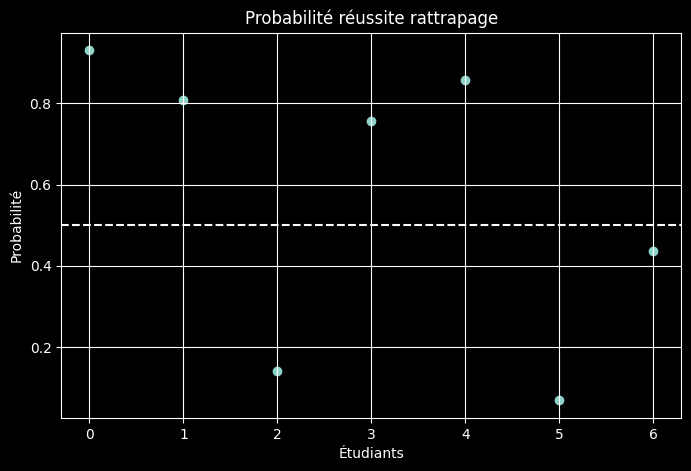

In [11]:

# VISUALISATION

plt.figure(figsize=(8,5))  # taille du graphique
plt.scatter(range(len(probas)), probas)  # affichage des probabilités
plt.axhline(y=0.5, linestyle='--')  # seuil de décision
plt.title("Probabilité réussite rattrapage")
plt.xlabel("Étudiants")
plt.ylabel("Probabilité")
plt.grid(True)
plt.show()

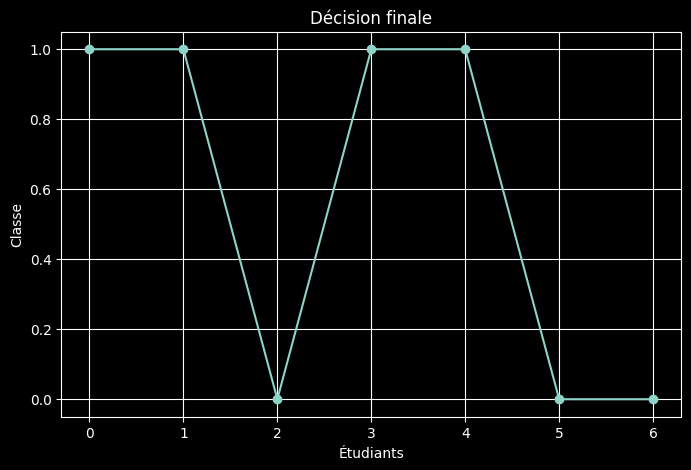

In [12]:

plt.figure(figsize=(8,5))  # second graphe
plt.plot(predictions, marker='o')  # évolution des décisions
plt.title("Décision finale")
plt.xlabel("Étudiants")
plt.ylabel("Classe")
plt.grid(True)
plt.show()  # affichage